# Partículas — boletín III

### Perspectiva experimental: aceleradores, interacción con la materia, detectores y del dato al resultado

José A. Hernando

*Departamento de Física de Partículas. Universidade de Santiago de Compostela*

Curso 2026/27

In [1]:
# Configuración e imports
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate, optimize
from scipy.interpolate import PchipInterpolator

# Paleta Okabe-Ito (apta para daltónicos)
C_SIG, C_BKG, C_AUX = '#0072B2', '#E69F00', '#009E73'
DATOS = 'datos/'

## Contenido

Soluciones del boletín III, con la misma numeración que el boletín en pdf. Siguen el orden de la perspectiva
experimental del capítulo de perspectivas:

* **Aceleradores.** 1 — La luminosidad de un colisionador.
* **Interacción con la materia.** 2 — Muones en la roca. 3 — La sección eficaz $\pi^+ + p$.
* **Detectores.** 4 — La sagitta. 5 — Tiempo de vuelo.
* **Del dato al resultado.** 6 — Eficiencia de un trigger de dos muones. 7 — Diseño de un trigger de muones (con
  datos). 8 — La sección eficaz $e^+ + e \to \pi^+ + \pi^-$. 9 — Leer un perfil de verosimilitud
  ($B_s^0 \to \mu^+ + \mu$ en CMS). 10 — Neutrinos de reactor: Poisson y Bayes. 11 — Leer una *posterior* (la masa
  del neutrino en KATRIN).

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 1 — La luminosidad de un colisionador</b></p>

Sea un colisionador donde $n$ paquetes que contienen $N$ partículas recorren un anillo con una frecuencia $\nu$ en
los dos sentidos. Al colisionar se reducen los paquetes a una sección transversal de radio $\sigma$. ¿Cuál es la
luminosidad del colisionador?

</div>

In [2]:
# Ejemplo numérico: LHC con los parámetros de diseño y paquetes gaussianos
n, N, nu, sig = 2808, 1.15e11, 11.245e3, 16.7e-4     # paquetes, protones/paquete, Hz, cm
L_unif  = n * N**2 * nu / (np.pi * sig**2)
L_gauss = n * N**2 * nu / (4 * np.pi * sig**2)
print('L (disco uniforme) = {:.1e} cm^-2 s^-1'.format(L_unif))
print('L (gaussiana)      = {:.1e} cm^-2 s^-1'.format(L_gauss))

L (disco uniforme) = 4.8e+34 cm^-2 s^-1
L (gaussiana)      = 1.2e+34 cm^-2 s^-1


<details>
<summary><b>Solución</b></summary>

$\mathcal{L}$ se define de forma que la tasa de un proceso de sección eficaz $\sigma_{int}$ sea
$R = \sigma_{int}\mathcal{L}$.

* **Un cruce.** Las $N$ partículas de un paquete se reparten sobre el área $A = \pi\sigma^2$; una partícula del
  otro paquete interacciona con probabilidad $N\sigma_{int}/A$ (la fracción del área cubierta por los $N$
  «discos» $\sigma_{int}$). Con $N$ partículas en el paquete que llega, $N_{int} = N^2\sigma_{int}/A$.
* **Cruces por segundo.** Con $n$ paquetes por haz y frecuencia de revolución $\nu$, hay $n\nu$ cruces por segundo
  en el punto de interacción.

$$
R = n\nu\,\frac{N^2}{A}\,\sigma_{int}
\quad\Rightarrow\quad
\mathcal{L} = \frac{n N^2 \nu}{\pi\sigma^2}.
$$

Si la distribución transversal es gaussiana de anchura $\sigma$ en $x$ e $y$, el área efectiva es la integral de
solapamiento, $1/A = \int\rho_1\rho_2\,\mathrm{d}x\,\mathrm{d}y = 1/(4\pi\sigma^2)$, y
$\mathcal{L} = nN^2\nu/(4\pi\sigma^2)$, la fórmula habitual. En los dos casos $\mathcal{L} \propto nN^2\nu/\sigma^2$:
$N^2$ porque interaccionan dos poblaciones, $1/\sigma^2$ porque apretar los haces concentra los blancos. En el LHC
la fórmula gaussiana da $\simeq 1.2\cdot10^{34}$ cm$^{-2}$s$^{-1}$, la luminosidad de diseño.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 2 — Muones en la roca</b></p>

Los muones de alta energía pierden energía atravesando la materia según

$$
\frac{1}{\rho}\frac{\mathrm{d}E}{\mathrm{d}x} \simeq a + bE,
$$

donde $a \simeq 2.5$ MeV cm$^2$/g está asociado a la pérdida por ionización y $b \simeq 3.5\cdot10^{-6}$ cm$^2$/g
a la radiación de frenado para roca. Considerar $A = 22$, $Z = 11$ y $\rho = 2.65$ g/cm$^3$.

(a) ¿A qué energía la pérdida por ionización es igual a la pérdida por *bremsstrahlung*?
(b) ¿Cuánta distancia recorre en promedio un muón cósmico de $100$ GeV en roca?

</div>

E_c = 714 GeV
X = 3.74e+04 g/cm^2  ->  R = 141 m   (solo ionización: 151 m)


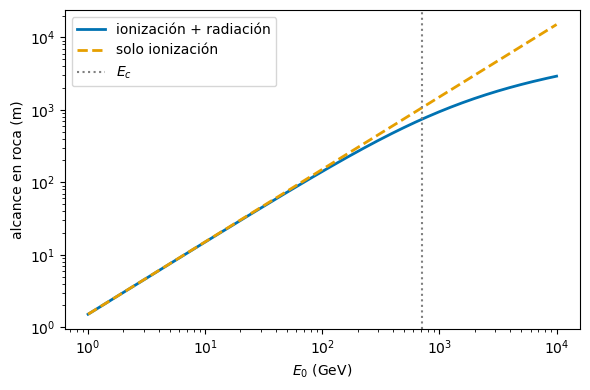

In [3]:
a, b, rho = 2.5, 3.5e-6, 2.65            # MeV cm^2/g, cm^2/g, g/cm^3
E0 = 1e5                                 # MeV
Ec = a / b
X  = np.log(1 + b * E0 / a) / b          # g/cm^2
print('E_c = {:.0f} GeV'.format(Ec / 1e3))
print('X = {:.2e} g/cm^2  ->  R = {:.0f} m   (solo ionización: {:.0f} m)'.format(X, X / rho / 100, E0 / a / rho / 100))

# alcance en función de la energía inicial
E = np.logspace(3, 7, 200)               # MeV
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(E / 1e3, np.log(1 + b * E / a) / b / rho / 100, color=C_SIG, lw=2, label='ionización + radiación')
ax.loglog(E / 1e3, E / a / rho / 100, color=C_BKG, ls='--', lw=2, label='solo ionización')
ax.axvline(Ec / 1e3, color='gray', ls=':', label='$E_c$')
ax.set_xlabel('$E_0$ (GeV)'); ax.set_ylabel('alcance en roca (m)'); ax.legend(); plt.tight_layout()

<details>
<summary><b>Solución</b></summary>

**(a)** La ionización es $\propto a$ y la radiación $\propto bE$; se igualan en la **energía crítica**

$$
E_c = \frac{a}{b} = \frac{2.5}{3.5\cdot10^{-6}}\ \text{MeV} \simeq 714\ \text{GeV}.
$$

Por debajo domina la ionización; por encima, la pérdida radiativa. Es mucho mayor que la del electrón
($E_c \simeq 610\ \text{MeV}/(Z+1.24) \simeq 50$ MeV en roca) porque la radiación va como $1/m^2$.

**(b)** Con $\mathrm{d}E/\mathrm{d}x = -\rho(a + bE)$, separando variables e integrando hasta $E \simeq 0$:

$$
R = \frac{1}{\rho b}\ln\left(\frac{a + bE_0}{a}\right),
\qquad
X = \rho R = \frac{1}{b}\ln\left(1 + \frac{bE_0}{a}\right).
$$

Con $E_0 = 10^5$ MeV, $bE_0 = 0.35$ MeV cm$^2$/g y $X \simeq 3.74\cdot10^{4}$ g/cm$^2$, luego
$R = X/\rho \simeq 1.41\cdot10^{4}$ cm $\simeq 141$ m. Solo con ionización serían $E_0/(\rho a) \simeq 151$ m: a
$100$ GeV la radiación apenas cuenta. Por eso los laboratorios subterráneos se miden en «metros equivalentes de
agua» y necesitan cientos de metros de roca para frenar los muones cósmicos.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 3 — La sección eficaz $\pi^+ + p$</b></p>

Para medir la sección eficaz de la interacción $\pi^+ + p$ enviamos un haz de $\pi^+$ de $20$ GeV de energía a un
tanque de longitud $L = 1$ m, que en una primera configuración está vacío y luego lleno de hidrógeno líquido, y
medimos los flujos tras el tanque normalizados al mismo flujo incidente y obtenemos $N_0 = 7.5\cdot10^5$ y
$N_H = 6.9\cdot10^5$. Calcula la sección eficaz y su error estadístico. Datos: $\rho_H = 60$ kg/m$^3$.

</div>

In [4]:
NA = 6.022e23
N0, NH, L = 7.5e5, 6.9e5, 100.0          # cm
n = 0.060 * NA / 1.0                     # protones/cm^3 (rho = 0.060 g/cm^3, A = 1 g/mol)
sigma  = -np.log(NH / N0) / (n * L)
dsigma = np.sqrt(1 / NH + 1 / N0) / (n * L)
print('n = {:.2e} cm^-3'.format(n))
print('sigma = ({:.1f} +- {:.1f}) mb'.format(sigma / 1e-27, dsigma / 1e-27))

n = 3.61e+22 cm^-3
sigma = (23.1 +- 0.5) mb


<details>
<summary><b>Solución</b></summary>

La fracción del haz que atraviesa el blanco sin interaccionar es

$$
\frac{N_H}{N_0} = e^{-n\sigma L}
\quad\Rightarrow\quad
\sigma = -\frac{1}{nL}\ln\frac{N_H}{N_0},
$$

con $n$ la densidad de protones. Con $\rho_H = 0.060$ g/cm$^3$ y $A_H \simeq 1$ g/mol,
$n = \rho_H N_A/A_H = 3.61\cdot10^{22}$ cm$^{-3}$, y con $L = 100$ cm:

$$
\sigma = 2.31\cdot10^{-26}\ \text{cm}^2 = 23.1\ \text{mb}.
$$

**Error estadístico.** $N_0$ y $N_H$ son de Poisson, $\delta N = \sqrt N$. Como
$\sigma = (\ln N_0 - \ln N_H)/(nL)$,

$$
\delta\sigma = \frac{1}{nL}\sqrt{\frac{1}{N_H} + \frac{1}{N_0}} = 0.46\ \text{mb},
\qquad
\sigma = (23.1 \pm 0.5)\ \text{mb}.
$$

Solo interacciona un $8\,\%$ del haz: el blanco es «delgado», y el error lo dominan las fluctuaciones de dos
números grandes casi iguales. El valor es el de la sección eficaz total $\pi^+ + p$ a esa energía.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 4 — La sagitta</b></p>

Considera un espectrómetro de longitud $L$ y campo magnético $B$ y tres cámaras de detección situadas antes, en
el medio y después del espectrómetro, que nos permiten estimar la *sagitta*

$$
s = x_2 - \frac{x_3 + x_1}{2}.
$$

Calcula el momento transverso de la partícula y su incertidumbre si la resolución de cada cámara es $\sigma_x$.
Considerar $\theta$ pequeño.

<img src="../imgs/bol3_sagitta.png" width=420>

</div>

In [5]:
def sagitta(pT, B, L):
    # s = L^2/(8R), con R = pT/(0.3 B)   [GeV, T, m]
    return L**2 * 0.3 * B / (8 * pT)

B, L, sx = 1.0, 1.0, 100e-6              # T, m, m
for pT in (1, 10, 100):
    s = sagitta(pT, B, L)
    print('pT = {:5.0f} GeV:  R = {:6.1f} m,  s = {:7.3f} mm,  sigma_pT/pT = {:5.1%}'.format(
          pT, pT / (0.3 * B), 1e3 * s, np.sqrt(1.5) * sx / s))

pT =     1 GeV:  R =    3.3 m,  s =  37.500 mm,  sigma_pT/pT =  0.3%
pT =    10 GeV:  R =   33.3 m,  s =   3.750 mm,  sigma_pT/pT =  3.3%
pT =   100 GeV:  R =  333.3 m,  s =   0.375 mm,  sigma_pT/pT = 32.7%


<details>
<summary><b>Solución</b></summary>

**Momento y radio.** El campo no hace trabajo: $|\vec p|$ y $\gamma$ son constantes y en el plano perpendicular a
$\vec B$ la trayectoria es una circunferencia. Igualando $p_T v_T/R = q v_T B$, $p_T = qBR$, válido
relativísticamente. En unidades prácticas,

$$
p_T\ [\text{GeV}] = 0.3\, B\ [\text{T}]\; R\ [\text{m}].
$$

**Sagitta y radio.** En el caso simétrico, Pitágoras en el triángulo centro–punto medio de la cuerda–extremo da
$(R-s)^2 + (L/2)^2 = R^2$, y con $s \ll R$, $s \simeq L^2/(8R)$. En general la traza entra inclinada; para
ángulos pequeños el arco es una parábola, $x(z) \simeq K - (z - z_c)^2/(2R)$, y evaluando en $z = 0, L/2, L$ los
términos en $z_c$ se cancelan: $s = L^2/(8R)$ con cualquier inclinación (una inclinación suma un término lineal,
que desplaza igual el arco y la cuerda). Por tanto

$$
p_T = \frac{0.3\,B L^2}{8 s}.
$$

**Incertidumbre.** Como $p_T \propto 1/s$, $\sigma_{p_T}/p_T = \sigma_s/s$. Con tres medidas independientes,
$\sigma_s^2 = \sigma_x^2 + 2(\sigma_x/2)^2 = \tfrac32\sigma_x^2$, y

$$
\frac{\sigma_{p_T}}{p_T} = \sqrt{\frac32}\,\frac{\sigma_x}{s} = \sqrt{\frac32}\,\frac{8\,\sigma_x}{0.3\,BL^2}\;p_T .
$$

La resolución relativa **empeora linealmente con $p_T$**: cuanto más rígida la traza, menor la sagitta. Y mejora
como $BL^2$: es más rentable alargar el espectrómetro que aumentar el campo. Con $B = 1$ T, $L = 1$ m y
$\sigma_x = 100\ \mu$m, un muón de $10$ GeV tiene $s \simeq 3.8$ mm y $\sigma_{p_T}/p_T \simeq 3\,\%$; a $100$ GeV,
un $30\,\%$.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 5 — Tiempo de vuelo</b></p>

Un sistema de tiempo de vuelo (TOF) consta de dos centelleadores separados una distancia $L$, que las partículas
atraviesan perpendicularmente; para cada partícula se mide el tiempo que tarda en ir del primero al segundo.

(a) Considera dos partículas de masas $m_1$, $m_2$ con el mismo momento $p$: ¿cuál es la diferencia entre sus
tiempos de vuelo?
(b) Si la resolución temporal de cada centelleador es de $300$ ps, ¿a qué distancia deben estar situados para
separar $\pi$ de $K$ de $4$ GeV de momento a $3$ desviaciones estándar?
(c) En un colisionador como el LHC, el instante de producción $t_0$ se conoce con precisión a partir del cruce de
los haces y del vértice de la colisión, y basta entonces con un único centelleador situado a una distancia $L$ del
punto de interacción. ¿A qué distancia debería estar para la misma separación? Supón despreciable la incertidumbre
en $t_0$.

</div>

dos centelleadores    : sigma = 424 ps  ->  L = 55 m
un centelleador + t0  : sigma = 300 ps  ->  L = 39 m
Delta t / L = 23.3 ps/m


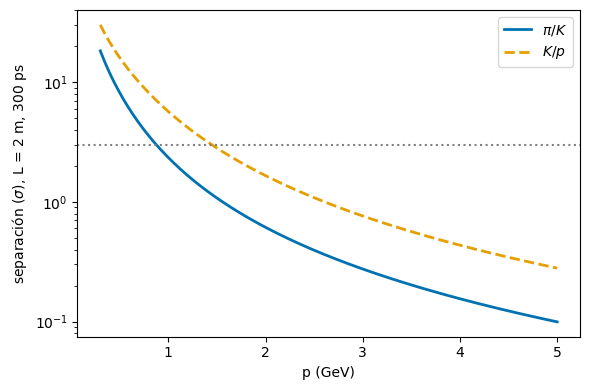

In [6]:
c_m_ps = 3.0e8 * 1e-12                   # m/ps
m_pi, m_K, p = 0.13957, 0.4937, 4.0      # GeV
beta = lambda m, p: p / np.sqrt(p**2 + m**2)
dt_L = (1 / beta(m_K, p) - 1 / beta(m_pi, p)) / c_m_ps          # ps/m
for nombre, sig_t in (('dos centelleadores', np.hypot(300, 300)), ('un centelleador + t0', 300.0)):
    print('{:22s}: sigma = {:.0f} ps  ->  L = {:.0f} m'.format(nombre, sig_t, 3 * sig_t / dt_L))
print('Delta t / L = {:.1f} ps/m'.format(dt_L))

# separación en sigmas para L = 2 m (un TOF real) en función del momento
pp = np.linspace(0.3, 5, 200)
fig, ax = plt.subplots(figsize=(6, 4))
for (m1, m2, lab, col, ls) in ((m_pi, m_K, r'$\pi/K$', C_SIG, '-'), (m_K, 0.93827, r'$K/p$', C_BKG, '--')):
    ax.plot(pp, (1 / beta(m2, pp) - 1 / beta(m1, pp)) * 2.0 / c_m_ps / 300, color=col, ls=ls, lw=2, label=lab)
ax.axhline(3, color='gray', ls=':')
ax.set_yscale('log'); ax.set_xlabel('p (GeV)'); ax.set_ylabel(r'separación ($\sigma$), L = 2 m, 300 ps')
ax.legend(); plt.tight_layout()

<details>
<summary><b>Solución</b></summary>

**(a)** $\beta = p/E = p/\sqrt{p^2 + m^2}$ y $t = L/(\beta c)$:

$$
\Delta t = \frac{L}{c}\left(\frac{1}{\beta_1} - \frac{1}{\beta_2}\right)
= \frac{L}{c}\left(\sqrt{1 + \frac{m_1^2}{p^2}} - \sqrt{1 + \frac{m_2^2}{p^2}}\right)
\simeq \frac{L}{2c}\,\frac{m_1^2 - m_2^2}{p^2}\quad(p \gg m).
$$

**(b)** A $4$ GeV, $\beta_\pi = 0.99939$ y $\beta_K = 0.99245$: $\Delta t/L \simeq 23.3$ ps/m. El tiempo de vuelo
es la diferencia de dos medidas independientes, $\sigma_{\Delta t} = \sqrt2\cdot300 = 424$ ps; a $3\sigma$ hacen
falta $1.27$ ns, es decir, $L \simeq 55$ m. Impracticable: a varios GeV el TOF no separa $\pi$ de $K$, y se usa
el Cherenkov.

**(c)** Con $t_0$ externo, $\sigma = 300$ ps, $3\sigma = 0.90$ ns y $L \simeq 39$ m: un factor $\sqrt2$ menos.
Es la idea de los detectores de tiempo de los experimentos del LHC: el $t_0$ del suceso sustituye al primer
centelleador. La figura muestra que con $L = 2$ m el TOF separa a $3\sigma$ $\pi/K$ hasta $\sim 0.9$ GeV y $K/p$ hasta $\sim 1.5$ GeV: como
$\Delta t \propto 1/p^2$, es una técnica de bajo momento.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 6 — Eficiencia de un trigger de dos muones</b></p>

El sistema de disparo de un experimento selecciona un muón con un momento transverso bajo $p_T > 4$ GeV (LPT) u
otro de alto momento con $p_T > 20$ GeV (HPT). La eficiencia para un muón de la desintegración
$Z^0 \to \mu^+ + \mu$ es del $89\,\%$ y del $62\,\%$ para LPT y HPT respectivamente. ¿Cuál sería la eficiencia para
un disparo basado en los dos muones del $Z^0$ con las siguientes configuraciones?

(a) LPT1 y LPT2. (b) HPT1 o HPT2.

</div>

In [7]:
# eficiencias por suceso con dos muones independientes
e_lpt, e_hpt = 0.89, 0.62
print('(a) LPT1 y LPT2: {:.1%}'.format(e_lpt**2))
print('(b) HPT1 o HPT2: {:.1%}'.format(1 - (1 - e_hpt)**2))

(a) LPT1 y LPT2: 79.2%
(b) HPT1 o HPT2: 85.6%


<details>
<summary><b>Solución</b></summary>

Suponemos que las eficiencias de los dos muones son independientes.

**(a)** «Y»: los dos muones tienen que pasar el corte LPT, $\varepsilon = \varepsilon^2_{LPT} = 0.89^2 \simeq
79\,\%$.

**(b)** «O»: basta con uno. Es más sencillo calcular el complementario, que no pase ninguno:
$\varepsilon = 1 - (1 - \varepsilon_{HPT})^2 = 1 - 0.38^2 \simeq 86\,\%$.

Pedir los dos muones cuesta eficiencia; aceptar cualquiera de los dos la recupera, aunque el corte por muón sea
más duro. La hipótesis de independencia se pone a prueba en el ejercicio siguiente.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 7 — Diseño de un trigger de muones (computación)</b></p>

Diseñas el trigger de muones de un experimento hacia delante como LHCb para buscar $B_s^0 \to \mu^+ + \mu$. El
primer nivel decide con **un solo muón**, con su momento $p$, su momento transverso $p_T$ y su parámetro de impacto
IP (la distancia mínima de la traza al vértice primario). Supón, aunque no sea del todo correcto, que todo el fondo
del trigger son muones de $J/\psi \to \mu^+ + \mu$ producidos en el vértice primario (*prompt*).

En `datos/trigger_bs2mumu.csv` y `datos/trigger_jpsi_prompt.csv` hay $10\,000$ sucesos simulados de cada tipo,
con los dos muones dentro de la aceptancia del detector ($2 < \eta < 5$ y $p > 6$ GeV); columnas
`p1, pt1, ip1, p2, pt2, ip2` ($p$ y $p_T$ en GeV, IP en $\mu$m).

Datos, con los dos muones dentro de la aceptancia: $\sigma(p + p \to J/\psi + X) = 6.8\ \mu$b y
$\mathcal{B}(J/\psi \to \mu^+ + \mu) = 5.96\,\%$; $\sigma(p + p \to B_s^0 + X) = 14\ \mu$b (sumando $B_s^0$ y
$\bar B_s^0$) y $\mathcal{B}(B_s^0 \to \mu^+ + \mu) = 3.6\cdot10^{-9}$. Luminosidad $\mathcal{L} = 2\cdot10^{33}$
cm$^{-2}$s$^{-1}$, y $\mathcal{L}_{int} = 5$ fb$^{-1}$ por año.

(a) Tasa de sucesos $J/\psi \to \mu^+ + \mu$ en la aceptancia: ¿cuántas veces supera los $20$ Hz asignados?
(b) Distribuciones de $p_T$ e IP: ¿qué variable separa mejor y por qué?
(c) El suceso pasa si **al menos un** muón cumple $p_T > p_T^{min}$ e IP $>$ IP$^{min}$. Elige los cortes para
$R \le 20$ Hz y da la eficiencia de la señal; compara cortes solo en $p_T$, solo en IP y en los dos. ¿Coincide la
eficiencia por suceso con la que predice la eficiencia por muón, como en el ejercicio anterior?
(d) ¿Y con $10$ Hz? ¿Con qué precisión conoces la tasa de fondo?
(e) ¿Cuántos $B_s^0 \to \mu^+ + \mu$ se graban en un año?

</div>

In [8]:
sig = pd.read_csv(DATOS + 'trigger_bs2mumu.csv')
bkg = pd.read_csv(DATOS + 'trigger_jpsi_prompt.csv')

# (a) tasa de fondo
lum   = 2e33                       # cm^-2 s^-1
R_bkg = 6.8e-30 * 0.0596 * lum
print('R(J/psi -> mu mu, en aceptancia) = {:.0f} Hz  ->  {:.0f} veces 20 Hz'.format(R_bkg, R_bkg / 20))
sig.head()

R(J/psi -> mu mu, en aceptancia) = 811 Hz  ->  41 veces 20 Hz


,p1,pt1,ip1,p2,pt2,ip2
0,316.15,9.906,365.4,289.54,6.636,432.3
1,41.83,3.994,96.2,34.83,1.998,67.8
2,46.65,8.628,117.1,6.58,1.664,906.5
3,58.39,6.347,20.6,42.97,1.745,80.1
4,479.73,8.953,88.3,90.82,3.516,624.5


mediana pt:  señal    3.1   fondo    1.8
mediana ip:  señal  299.9   fondo   36.7


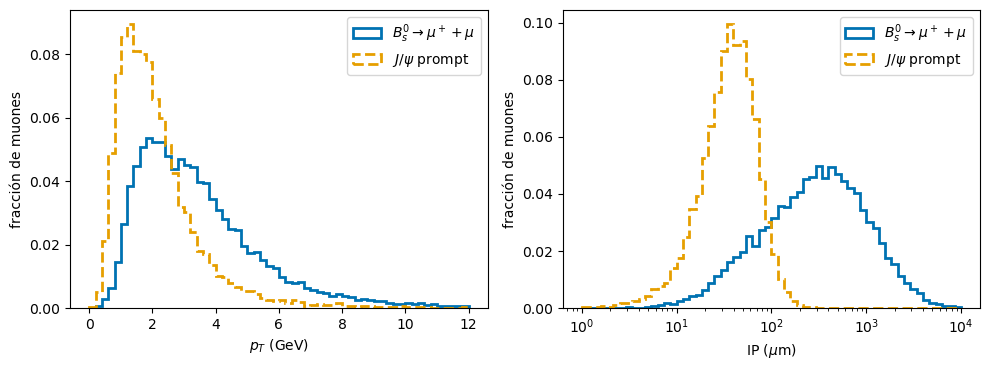

In [9]:
# (b) distribuciones por muón (los dos muones de cada suceso)
def muones(df, var):
    return np.r_[df[var + '1'], df[var + '2']]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, var, bins, lab in [(axs[0], 'pt', np.linspace(0, 12, 61), r'$p_T$ (GeV)'),
                           (axs[1], 'ip', np.logspace(0, 4, 61), r'IP ($\mu$m)')]:
    for df, col, ls, lb in ((sig, C_SIG, '-', r'$B_s^0 \to \mu^+ + \mu$'), (bkg, C_BKG, '--', r'$J/\psi$ prompt')):
        v = muones(df, var)
        ax.hist(v, bins, weights=np.full(len(v), 1 / len(v)), histtype='step', lw=2, color=col, ls=ls, label=lb)
    ax.set_xlabel(lab); ax.set_ylabel('fracción de muones'); ax.legend()
axs[1].set_xscale('log')
plt.tight_layout()
for var in ('pt', 'ip'):
    print('mediana {:2s}:  señal {:6.1f}   fondo {:6.1f}'.format(var, np.median(muones(sig, var)),
                                                            np.median(muones(bkg, var))))

In [10]:
# (c) eficiencia por suceso: al menos un muón con pT > ptmin e IP > ipmin
def pasa(df, ptmin, ipmin):
    m1 = (df.pt1 > ptmin) & (df.ip1 > ipmin)
    m2 = (df.pt2 > ptmin) & (df.ip2 > ipmin)
    return m1 | m2, np.r_[m1, m2]

def eff(df, ptmin, ipmin):
    ev, mu = pasa(df, ptmin, ipmin)
    return ev.mean(), mu.mean()

def corte_minimo(budget, var, grid):
    # primer corte de la rejilla que deja la tasa por debajo del presupuesto
    for x in grid:
        cut = (x, 0) if var == 'pt' else (0, x)
        if R_bkg * eff(bkg, *cut)[0] <= budget:
            return cut

def mejor_corte(budget):
    # para cada corte en pT, el corte en IP mínimo que cumple el presupuesto; se queda con el de más señal
    best = None
    for pt in np.arange(0, 4.01, 0.25):
        for ip in np.arange(0, 300, 1):
            if R_bkg * eff(bkg, pt, ip)[0] <= budget:
                e = eff(sig, pt, ip)[0]
                if best is None or e > best[0]:
                    best = (e, pt, ip)
                break
    return best[1:]

for budget in (20, 10):
    print('--- {} Hz'.format(budget))
    cortes = {'solo pT ': corte_minimo(budget, 'pt', np.arange(0, 15, 0.1)),
              'solo IP ': corte_minimo(budget, 'ip', np.arange(0, 400, 1)),
              'pT e IP ': mejor_corte(budget)}
    for nombre, (pt, ip) in cortes.items():
        es, emu = eff(sig, pt, ip)
        nb = pasa(bkg, pt, ip)[0].sum()
        print('{}: pT > {:4.1f} GeV, IP > {:3.0f} um   R = {:4.1f} Hz   eff(Bs) = {:.2f}   '
              'eff/muón = {:.2f} -> 1-(1-e)^2 = {:.2f}   N_fondo = {} ({:.0%})'.format(
              nombre, pt, ip, R_bkg * eff(bkg, pt, ip)[0], es, emu, 1 - (1 - emu)**2, nb, 1 / np.sqrt(nb)))

--- 20 Hz


solo pT : pT >  7.3 GeV, IP >   0 um   R = 19.6 Hz   eff(Bs) = 0.11   eff/muón = 0.06 -> 1-(1-e)^2 = 0.12   N_fondo = 242 (6%)
solo IP : pT >  0.0 GeV, IP > 132 um   R = 19.7 Hz   eff(Bs) = 0.84   eff/muón = 0.72 -> 1-(1-e)^2 = 0.92   N_fondo = 243 (6%)
pT e IP : pT >  1.0 GeV, IP >  97 um   R = 19.9 Hz   eff(Bs) = 0.87   eff/muón = 0.77 -> 1-(1-e)^2 = 0.95   N_fondo = 246 (6%)
--- 10 Hz


solo pT : pT >  8.8 GeV, IP >   0 um   R =  9.6 Hz   eff(Bs) = 0.06   eff/muón = 0.03 -> 1-(1-e)^2 = 0.06   N_fondo = 119 (9%)
solo IP : pT >  0.0 GeV, IP > 150 um   R = 10.0 Hz   eff(Bs) = 0.81   eff/muón = 0.69 -> 1-(1-e)^2 = 0.90   N_fondo = 123 (9%)
pT e IP : pT >  1.0 GeV, IP > 108 um   R =  9.6 Hz   eff(Bs) = 0.85   eff/muón = 0.75 -> 1-(1-e)^2 = 0.94   N_fondo = 119 (9%)


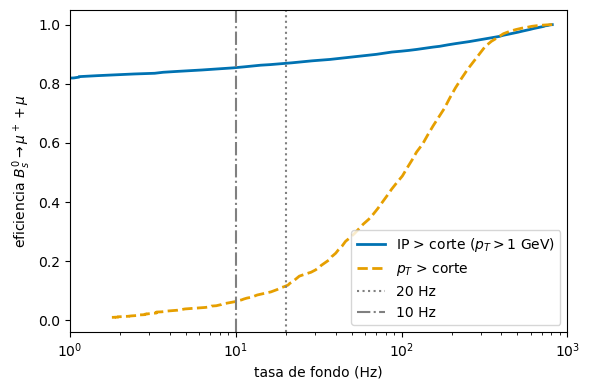

In [11]:
# (d) curva eficiencia de señal frente a tasa: corte en IP (pT > 1 GeV) y corte en pT
ips = np.arange(0, 400, 2)
pts = np.arange(0, 15, 0.1)
r_ip = [R_bkg * eff(bkg, 1.0, x)[0] for x in ips];  e_ip = [eff(sig, 1.0, x)[0] for x in ips]
r_pt = [R_bkg * eff(bkg, x, 0)[0] for x in pts];    e_pt = [eff(sig, x, 0)[0] for x in pts]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_ip, e_ip, color=C_SIG, ls='-',  lw=2, label=r'IP > corte ($p_T > 1$ GeV)')
ax.plot(r_pt, e_pt, color=C_BKG, ls='--', lw=2, label=r'$p_T$ > corte')
for b, ls in ((20, ':'), (10, '-.')):
    ax.axvline(b, color='gray', ls=ls, label='{} Hz'.format(b))
ax.set_xscale('log'); ax.set_xlim(1, 1e3)
ax.set_xlabel('tasa de fondo (Hz)'); ax.set_ylabel(r'eficiencia $B_s^0 \to \mu^+ + \mu$')
ax.legend(); plt.tight_layout()

In [12]:
# (e) sucesos B_s -> mu mu grabados en un año
pt, ip   = mejor_corte(20)
eff_trig = eff(sig, pt, ip)[0]
N = 14e-30 * 3.6e-9 * eff_trig * 5e39
print('eff_trig = {:.2f}   ->   N = {:.0f} sucesos/año'.format(eff_trig, N))

eff_trig = 0.87   ->   N = 219 sucesos/año


<details>
<summary><b>Solución</b></summary>

**(a)** $R = \sigma\,\mathcal{B}\,\mathcal{L} \simeq 8\cdot10^{2}$ Hz, unas $40$ veces el presupuesto: el trigger
solo puede quedarse con un $2.5\,\%$ del fondo.

**(b)** El **IP** separa mucho mejor (medianas de $\sim 300$ frente a $\sim 37\ \mu$m). El $B_s^0$ vuela
$c\tau = 456\ \mu$m (por $\beta\gamma$) antes de desintegrarse, y el IP de sus muones es del orden de $c\tau$; el
$J/\psi$ prompt nace en el vértice primario, y su IP es solo la resolución, $\sigma_{IP} \simeq (15 + 29/p_T)\
\mu$m. El $p_T$ separa menos: los muones llevan $p^* \simeq m/2$ en el reposo de la madre ($2.7$ frente a $1.5$
GeV), pero los espectros de las madres son anchos y se solapan.

**(c)** Con $20$ Hz: solo $p_T > 7.3$ GeV deja un $11\,\%$ de la señal; solo IP $> 132\ \mu$m, un $84\,\%$;
$p_T > 1$ GeV e IP $> 97\ \mu$m, un $87\,\%$. El IP hace casi todo el trabajo; el corte suave en $p_T$ ayuda
porque la resolución en IP empeora a $p_T$ bajo. La eficiencia por muón es $0.77$, y con muones independientes,
como en el ejercicio 6, el «o» daría $1-(1-0.77)^2 = 0.95$, pero se mide $0.87$: los dos muones salen del mismo
vértice, y si el $B_s^0$ se desintegra pronto los dos tienen IP pequeño a la vez. Están **correlacionados**.

**(d)** Con $10$ Hz se pierden solo dos puntos ($85\,\%$), porque la cola de IP del fondo cae muy deprisa; con
el corte en $p_T$ la eficiencia se hunde al $6\,\%$. La tasa se estima con unos $250$ sucesos de fondo que
pasan el corte ($120$ para $10$ Hz): una precisión del $6\,\%$ ($9\,\%$). Para fijar un trigger real hacen falta
muestras de fondo mucho mayores.

**(e)** $N = \sigma\,\mathcal{B}\,\varepsilon_{trig}\,\mathcal{L}_{int} \simeq 2\cdot10^{2}$ sucesos al año,
antes de la selección final: el trigger tiene que ser muy eficiente.

*Nota.* Las muestras son de juguete (espectros sencillos, desintegración isótropa y la resolución en IP de LHCb):
se generan con `tools/gen_trigger_bsmumu.py`. En un experimento real el fondo de un trigger de muones lo dominan
los $\pi$ y $K$ que se desintegran en vuelo y las desintegraciones semileptónicas de $c$ y $b$.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 8 — La sección eficaz $e^+ + e \to \pi^+ + \pi^-$ y el factor de forma del pión</b></p>

Estima la sección eficaz (y sus errores estadísticos y sistemáticos) de $e^+ + e \to \pi^+ + \pi^-$ a
$\sqrt{s} = 1$ GeV con los datos que obtuvo el siguiente experimento: con una luminosidad integrada de
$\mathcal{L}_{int} = 2.43$ nb$^{-1}$ se observaron $128$ sucesos candidatos, la eficiencia de selección se estimó en
$\varepsilon = (52 \pm 2)\,\%$ y el fondo en $N_B = 14 \pm 1.8$ sucesos.

La sección eficaz se espera teóricamente que sea

$$
\sigma(s) = \frac{\pi\alpha^2}{3s}\,\beta_\pi^3\,|F(s)|^2,
$$

donde $\beta_\pi$ es la velocidad del pión en unidades de $c$, $\alpha$ la constante de estructura fina y $F(s)$ un
factor teórico. ¿Puedes estimar el valor y la incertidumbre de $|F(s)|$ a partir de las medidas del experimento?

</div>

In [13]:
Lint, Nobs, NB, dNB, eps, deps = 2.43, 128, 14, 1.8, 0.52, 0.02     # nb^-1, sucesos, -, -
sig  = (Nobs - NB) / (Lint * eps)
dst  = np.sqrt(Nobs) / (Lint * eps)
dsy  = np.hypot(dNB / (Lint * eps), sig * deps / eps)
print('sigma = ({:.1f} +- {:.1f} stat +- {:.1f} sist) nb'.format(sig, dst, dsy))

s, alpha, GeV2nb = 1.0, 1 / 137.036, 3.8938e5                         # GeV^2, -, nb GeV^2
b_pi = np.sqrt(1 - 4 * 0.13957**2 / s)
F = np.sqrt(3 * sig / GeV2nb * s / (np.pi * alpha**2 * b_pi**3))
print('beta_pi = {:.4f},  |F| = {:.2f} +- {:.2f} stat +- {:.2f} sist,  |F|^2 = {:.1f}'.format(
      b_pi, F, F * dst / sig / 2, F * dsy / sig / 2, F**2))

sigma = (90.2 +- 9.0 stat +- 3.8 sist) nb
beta_pi = 0.9603,  |F| = 2.17 +- 0.11 stat +- 0.05 sist,  |F|^2 = 4.7


<details>
<summary><b>Solución</b></summary>

**Sección eficaz.** $N_S = N_{obs} - N_B = 114$ y $N_S = \sigma\,\mathcal{L}_{int}\,\varepsilon$, luego
$\sigma = 114/(2.43 \cdot 0.52) = 90.2$ nb.

* **Estadístico:** Poisson del número observado, $\delta\sigma_{stat} = \sqrt{128}/(\mathcal{L}_{int}\varepsilon)
  = 9.0$ nb.
* **Sistemático:** del fondo, $1.8/(\mathcal{L}_{int}\varepsilon) = 1.42$ nb; de la eficiencia,
  $\sigma\,\delta\varepsilon/\varepsilon = 90.2 \cdot 2/52 = 3.47$ nb; en cuadratura, $3.75$ nb.

$$
\sigma = (90.2 \pm 9.0_{stat} \pm 3.8_{sist})\ \text{nb}.
$$

**Factor de forma.** En un colisionador simétrico cada pión lleva $E_\pi = \sqrt s/2$, y
$\beta_\pi = \sqrt{1 - 4m_\pi^2/s} = 0.960$. El factor $\beta_\pi^3$ tiene dos orígenes: un $\beta_\pi$ del espacio
fásico y $\beta_\pi^2$ de que dos piones sin espín producidos por un fotón virtual (espín 1) salen en onda P. Esa
onda P da $\mathrm{d}\sigma/\mathrm{d}\Omega \propto \sin^2\theta$, y al integrar aparece el $1/3$ frente a
$\sigma(e^+ + e \to \mu^+ + \mu) = 4\pi\alpha^2/(3s)$, que va como $1 + \cos^2\theta$. Despejando, con
$1$ GeV$^{-2} = 3.8938\cdot10^5$ nb,

$$
|F(s)| = \sqrt{\frac{3\sigma s}{\pi\alpha^2\beta_\pi^3}} \simeq 2.17,
\qquad |F|^2 \simeq 4.7 .
$$

Como $|F| \propto \sqrt\sigma$, $\delta F/F = \tfrac12\,\delta\sigma/\sigma$:
$|F| = 2.17 \pm 0.11_{stat} \pm 0.05_{sist}$. Un pión puntual tendría $|F| = 1$: $|F|^2 \simeq 4.7$ refleja la
estructura del pión, la cola de la resonancia $\rho$ ($m_\rho = 775$ MeV), que domina la producción de dos piones
a estas energías.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 9 — Leer un perfil de verosimilitud: $B_s^0 \to \mu^+ + \mu$ en CMS</b></p>

La figura muestra el resultado de CMS para la fracción de desintegración $\mathcal{B}(B_s^0 \to \mu^+ + \mu)$ con
$140$ fb$^{-1}$ a $\sqrt s = 13$ TeV: el perfil de verosimilitud $-2\ln(L/L_{max})$ en función de
$\mathcal{B}(B_s^0 \to \mu^+ + \mu)$. El modelo estándar predice
$\mathcal{B}_{SM}(B_s^0 \to \mu^+ + \mu) = (3.66 \pm 0.14)\cdot10^{-9}$.

(a) ¿Qué representa la curva? ¿Cuál es el valor central de la medida?
(b) El error a $1\sigma$ corresponde a $-2\Delta\ln L = 1$, que con esta escala no se puede leer. Lee la curva en
$\mathcal{B} = 3$ y $5\cdot10^{-9}$ y, suponiendo que cerca del mínimo
$-2\Delta\ln L \simeq (\mathcal{B}-\hat{\mathcal{B}})^2/\sigma^2$, estima el error por cada lado. ¿Es simétrico?
¿Por qué?
(c) ¿Con qué significancia se ha observado la desintegración? (Usa el valor de la curva en $\mathcal{B} = 0$.)
(d) ¿Es compatible la medida con el modelo estándar?

<img src="../imgs/bol3_bsmumu_cms_nll1d.png" width=400>

CMS, [Phys. Lett. B 842 (2023) 137955](https://arxiv.org/abs/2212.10311) (CC BY 4.0).

</div>

mínimo en B = 3.85e-9;  -2DlnL = 1 en [3.44, 4.26]
B = 0e-9:  -2DlnL = 157.0   sigma = 0.31
B = 2e-9:  -2DlnL =  27.7   sigma = 0.35
B = 3e-9:  -2DlnL =   4.8   sigma = 0.39
B = 5e-9:  -2DlnL =   6.9   sigma = 0.44
B = 6e-9:  -2DlnL =  21.0   sigma = 0.47
B = 8e-9:  -2DlnL =  62.1   sigma = 0.53
B = 0:  -2DlnL =  157.0   Z = 12.5 sigma   p(1 cola) = 2.6e-36   p(2 colas) = 5.2e-36
SM   :  -2DlnL =    0.2   Z =  0.4 sigma   p(1 cola) = 3.3e-01   p(2 colas) = 6.5e-01


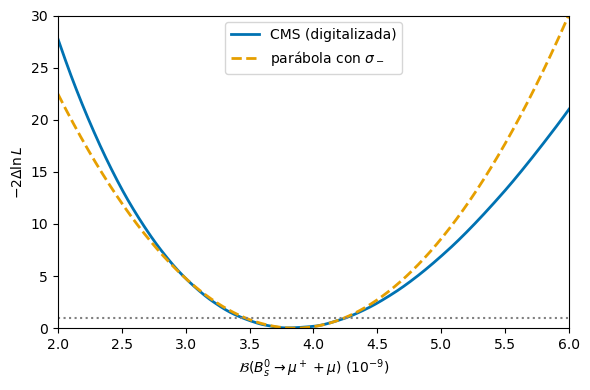

In [14]:
# Curva digitalizada del PDF vectorial de la figura (puntos del trazo publicado)
cms = pd.read_csv(DATOS + 'bsmumu_cms_nll1d_digitalizado.csv', comment='#')
f = PchipInterpolator(cms.br, cms.m2dlnl)
x = np.linspace(0, 8, 8001); y = f(x)
# el trazo está muestreado cada ~0.2: el mínimo se toma de una parábola a los puntos con -2DlnL < 3
near = cms.m2dlnl < 3
a2, a1, a0 = np.polyfit(cms.br[near], cms.m2dlnl[near], 2)
bh = -a1 / (2 * a2); i = np.searchsorted(x, bh)
lo = x[:i][np.argmin(abs(y[:i] - 1))]; hi = x[i:][np.argmin(abs(y[i:] - 1))]
print('mínimo en B = {:.2f}e-9;  -2DlnL = 1 en [{:.2f}, {:.2f}]'.format(bh, lo, hi))
for b in (0, 2, 3, 5, 6, 8):
    print('B = {}e-9:  -2DlnL = {:5.1f}   sigma = {:.2f}'.format(b, f(b), abs(b - bh) / np.sqrt(f(b))))

# (c) y (d): Wilks, -2DlnL ~ chi2(1) -> Z = sqrt(-2DlnL)
for nombre, b in (('B = 0', 0.0), ('SM   ', 3.66)):
    q = float(f(b))
    # p-valor de una cola (descubrimiento: solo cuenta un exceso) y de dos colas (compatibilidad)
    print('{}:  -2DlnL = {:6.1f}   Z = {:4.1f} sigma   p(1 cola) = {:.1e}   p(2 colas) = {:.1e}'.format(
          nombre, q, np.sqrt(q), stats.norm.sf(np.sqrt(q)), stats.chi2.sf(q, 1)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, color=C_SIG, lw=2, label='CMS (digitalizada)')
sm = (bh - 3) / np.sqrt(f(3))
ax.plot(x, (x - bh)**2 / sm**2, color=C_BKG, ls='--', lw=2, label=r'parábola con $\sigma_-$')
ax.axhline(1, color='gray', ls=':')
ax.set_ylim(0, 30); ax.set_xlim(2, 6)
ax.set_xlabel(r'$\mathcal{B}(B_s^0 \to \mu^+ + \mu)\ (10^{-9})$'); ax.set_ylabel(r'$-2\Delta\ln L$')
ax.legend(); plt.tight_layout()

<details>
<summary><b>Solución</b></summary>

**(a) La verosimilitud y su perfil.** La *verosimilitud* $L(\mathcal{B})$ es la probabilidad de obtener los datos
observados si la fracción de desintegración vale $\mathcal{B}$, vista como función de $\mathcal{B}$ con los datos
fijos; su máximo, $\hat{\mathcal{B}}$, es el estimador de máxima verosimilitud. El ajuste tiene además *parámetros
molestos* que no se conocen con exactitud (fondo, eficiencias, normalización, $\mathcal{B}(B^0 \to \mu^+ + \mu)$).
El **perfil** se obtiene fijando $\mathcal{B}$ en cada punto y volviendo a maximizar $L$ respecto a todos los demás:
la curva es ese barrido (*likelihood scan*), $-2\ln[L(\mathcal{B})/L_{max}]$, que vale cero en el mínimo y cuya
anchura incluye la incertidumbre estadística y la sistemática. El mínimo está en
$\hat{\mathcal{B}} \simeq 3.9\cdot10^{-9}$ (el artículo da $4.02$; la curva es muy plana cerca del mínimo).

**(b) El error.** Si la verosimilitud es gaussiana, $-2\Delta\ln L = (\mathcal{B}-\hat{\mathcal{B}})^2/\sigma^2$ es
una parábola, y el intervalo $-2\Delta\ln L \le 1$ es $\hat{\mathcal{B}} \pm \sigma$: contiene el valor verdadero
con un $68.3\,\%$ de probabilidad ($-2\Delta\ln L \le 4$, el $95.4\,\%$). Es lo que pasa con muchos sucesos (teorema
de Wilks); si la curva no es una parábola, el intervalo $-2\Delta\ln L \le 1$ se sigue usando como intervalo al
$68\,\%$, pero es asimétrico y su cobertura solo aproximada. Se lee $\simeq 5$ en $3\cdot10^{-9}$ y $\simeq 7$ en
$5\cdot10^{-9}$: $\sigma_- \simeq 0.9/\sqrt5 \simeq 0.4$ y $\sigma_+ \simeq 1.1/\sqrt7 \simeq 0.45$, es decir,
$\mathcal{B} \simeq (3.9^{+0.45}_{-0.4})\cdot10^{-9}$ (el artículo da, en total, $^{+0.52}_{-0.47}$).

**No es simétrico** porque la medida es un recuento: el número de sucesos de señal es $\propto \mathcal{B}$ y sigue
una distribución de Poisson, cuya varianza crece con el número de sucesos; un $\mathcal{B}$ mayor que el medido
predice fluctuaciones mayores y es menos improbable que uno menor a la misma distancia. Además, las incertidumbres
de eficiencia y normalización son multiplicativas y pesan más cuanto mayor es $\mathcal{B}$. La asimetría crece al
alejarse del mínimo (en $2$ y $6\cdot10^{-9}$, $\sigma \simeq 0.35$ y $0.47$).

**(c) Excluir $\mathcal{B} = 0$.** La curva vale $\simeq 157$. Por el teorema de Wilks, si $\mathcal{B} = 0$ fuera
cierto, $-2\Delta\ln L(0)$ se distribuiría como una $\chi^2$ con un grado de libertad (el cuadrado de una gaussiana
normalizada): $Z \simeq \sqrt{157} \simeq 12.5\sigma$. El p-valor (de una cola, porque solo un exceso
de sucesos indica señal), $p \simeq 3\cdot10^{-36}$, es la probabilidad
de que, **sin** señal, el fondo fluctuara hasta dar unos datos tan incompatibles con $\mathcal{B} = 0$; no es la
probabilidad de que $\mathcal{B} = 0$. El descubrimiento se fija en $5\sigma$ ($p \simeq 3\cdot10^{-7}$). Una
parábola con $\sigma_- = 0.4$ daría en cero $(3.9/0.4)^2 \simeq 95$, no $157$: lejos del mínimo la verosimilitud no
es gaussiana, y la significancia se lee en la curva, no se extrapola de los errores.

**(d)** En $\mathcal{B}_{SM}$ la curva vale $\simeq 0.2$: $Z \simeq 0.5\sigma$, $p \simeq 0.65$. Plenamente
compatible; la incertidumbre de la predicción ($0.14$) es despreciable frente a la de la medida.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 10 — Neutrinos de reactor: Poisson y Bayes</b></p>

Un experimento de neutrinos opera cerca de una central nuclear. La estimación del experimento es que interaccionan
$1.2$ neutrinos al día provenientes de la central y que la eficiencia de detección es del $62\,\%$. Primero
operaron el detector mientras la central permaneció parada durante $50$ días y observaron $3$ sucesos similares a
los esperados.

(a) ¿Qué probabilidad hay de que cuando la central entre en funcionamiento observe al menos $1$ suceso el primer
día?
(b) Si se observa un suceso, ¿cuál es la probabilidad de que sea espurio?

</div>

In [15]:
lam_S = 1.2 * 0.62                       # sucesos/día de la central
lam_B = 3 / 50                           # sucesos/día de fondo
lam   = lam_S + lam_B
print('lambda_S = {:.3f}, lambda_B = {:.3f}, lambda = {:.3f} por día'.format(lam_S, lam_B, lam))
print('(a) P(N >= 1) = {:.1%}'.format(1 - stats.poisson.pmf(0, lam)))

# (b) Bayes: P(B | N=1) = P(N=1 | B) P(B) / P(N=1); con N = 1 el suceso es de fondo o de señal
p1  = stats.poisson.pmf(1, lam)
pB1 = stats.poisson.pmf(1, lam_B) * stats.poisson.pmf(0, lam_S) / p1
print('(b) P(espurio | N = 1) = {:.1%}   (= lambda_B/lambda = {:.1%})'.format(pB1, lam_B / lam))

# el fondo se conoce solo con 3 sucesos: ¿cuánto cambia (b)?
for nb in (1, 3, 6):
    print('    con {} sucesos de fondo en 50 días: {:.1%}'.format(nb, (nb / 50) / (lam_S + nb / 50)))

lambda_S = 0.744, lambda_B = 0.060, lambda = 0.804 por día
(a) P(N >= 1) = 55.2%
(b) P(espurio | N = 1) = 7.5%   (= lambda_B/lambda = 7.5%)
    con 1 sucesos de fondo en 50 días: 2.6%
    con 3 sucesos de fondo en 50 días: 7.5%
    con 6 sucesos de fondo en 50 días: 13.9%


<details>
<summary><b>Solución</b></summary>

Los sucesos de la central y los de fondo son de Poisson, con $\lambda_S = 1.2 \cdot 0.62 = 0.744$ y
$\lambda_B = 3/50 = 0.060$ sucesos al día.

**(a)** Con la central en marcha, $\lambda = \lambda_S + \lambda_B = 0.804$, y

$$
P(N \ge 1) = 1 - P(N = 0) = 1 - e^{-\lambda} \simeq 55\,\%.
$$

**(b)** Por el teorema de Bayes, con un solo suceso observado,

$$
P(B\,|\,N=1) = \frac{P(N=1\,|\,B)\,P(B)}{P(N=1)}
= \frac{\lambda_B e^{-\lambda_B}\,e^{-\lambda_S}}{\lambda e^{-\lambda}}
= \frac{\lambda_B}{\lambda_B + \lambda_S} \simeq 7.5\,\%.
$$

Es la fracción de la tasa total que es fondo. El resultado supone que el fondo medido con la central parada es el
mismo con la central en marcha, y está mal conocido: con $3$ sucesos, $\lambda_B$ tiene un error del $\sim 60\,\%$,
y la probabilidad de (b) podría estar entre un $3$ y un $14\,\%$.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 11 — Leer una <i>posterior</i>: la masa del neutrino en KATRIN</b></p>

En su segunda campaña KATRIN obtuvo, con un ajuste frecuentista, $m_\nu^2 = (0.26 \pm 0.34)$ eV$^2$ y
$m_\nu < 0.9$ eV al $90\,\%$ CL. La figura es la *posterior* de $m_\nu^2$ de los mismos datos con una *prior*
plana en $m_\nu^2 \ge 0$, en intervalos de $0.01$ eV$^2$.

(a) ¿Qué representa la posterior? ¿Por qué empieza en $m_\nu^2 = 0$ con un valor distinto de cero?
(b) ¿Dónde está el máximo? (c) Estima $P(m_\nu^2 < 0.25$ eV$^2)$. (d) Límite en $m_\nu$ al $90\,\%$ de
credibilidad; compáralo con el frecuentista. (e) Reprodúcelo con una verosimilitud gaussiana $(0.26, 0.34)$ y la
prior plana. (f) Repite con una prior plana en $m_\nu$. (g) ¿Y si el ajuste hubiera dado $m_\nu^2 = -0.5 \pm 0.34$
eV$^2$?

<img src="../imgs/bol3_katrin_knm2_posterior.png" width=420>

KATRIN, [Nature Phys. 18 (2022) 160](https://arxiv.org/abs/2105.08533) (CC BY 4.0).

</div>

m2_fit =  0.26, prior plana en m2:  m2 < 0.74 eV^2,  m < 0.86 eV
m2_fit =  0.26, prior plana en m :  m2 < 0.61 eV^2,  m < 0.78 eV
m2_fit = -0.50, prior plana en m2:  m2 < 0.33 eV^2,  m < 0.58 eV


P(m2 < 0.25) = 0.35


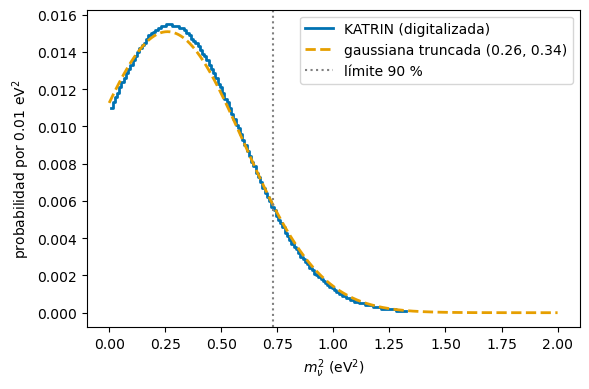

In [16]:
# (e)-(g) posterior = verosimilitud gaussiana en m^2 x prior, normalizada; límite al 90 %
def limite90(mu, s, prior='m2'):
    if prior == 'm2':
        post = lambda t: stats.norm.pdf(t, mu, s)                 # prior plana en m^2 >= 0
    else:
        post = lambda t: stats.norm.pdf(t, mu, s) / np.sqrt(t)    # prior plana en m: pi(m^2) ~ 1/m
    Z = integrate.quad(post, 0, 10, points=[1e-9])[0]
    q = optimize.brentq(lambda u: integrate.quad(post, 0, u, points=[1e-9])[0] / Z - 0.9, 1e-6, 5)
    return q, np.sqrt(q)

for mu, prior in ((0.26, 'm2'), (0.26, 'm'), (-0.5, 'm2')):
    q, m = limite90(mu, 0.34, prior)
    print('m2_fit = {:5.2f}, prior plana en {:2s}:  m2 < {:.2f} eV^2,  m < {:.2f} eV'.format(mu, prior, q, m))

# comparación con la posterior publicada (digitalizada)
kat = pd.read_csv(DATOS + 'katrin_knm2_posterior_digitalizado.csv', comment='#')
c = 0.5 * (kat.m2_lo + kat.m2_hi)
t = np.linspace(0, 2, 401)
g = stats.norm.pdf(t, 0.26, 0.34) / (1 - stats.norm.cdf(0, 0.26, 0.34)) * 0.01   # prob. por intervalo de 0.01
fig, ax = plt.subplots(figsize=(6, 4))
ax.step(c, kat.prob, where='mid', color=C_SIG, lw=2, label='KATRIN (digitalizada)')
ax.plot(t, g, color=C_BKG, ls='--', lw=2, label='gaussiana truncada (0.26, 0.34)')
ax.axvline(0.73, color='gray', ls=':', label=r'límite 90 %')
ax.set_xlabel(r'$m_\nu^2$ (eV$^2$)'); ax.set_ylabel('probabilidad por 0.01 eV$^2$')
ax.legend(); plt.tight_layout()
print('P(m2 < 0.25) = {:.2f}'.format(kat.prob[c < 0.25].sum() / kat.prob.sum()))

<details>
<summary><b>Solución</b></summary>

**(a)** $p(m_\nu^2\,|\,\text{datos}) \propto L(\text{datos}\,|\,m_\nu^2)\,\pi(m_\nu^2)$: la verosimilitud por la
prior, normalizada. La prior es nula para $m_\nu^2 < 0$, así que la posterior es la verosimilitud **cortada** en
cero; como el mejor ajuste está a menos de $1\sigma$ de cero, en $m_\nu^2 = 0$ la posterior no es pequeña.

**(b)** En $m_\nu^2 \simeq 0.26$ eV$^2$: con prior plana, posterior y verosimilitud tienen el mismo máximo.

**(c)** $25$ intervalos de altura media $\simeq 0.0135$: $P \simeq 0.34$.

**(d)** $m_\nu^2 < 0.73$ eV$^2$, $m_\nu < 0.85$ eV al $90\,\%$ de credibilidad: con esta prior y estos datos, la
probabilidad de que $m_\nu < 0.85$ eV es del $90\,\%$. El límite frecuentista ($0.9$ eV) habla del procedimiento:
el intervalo así construido contiene el valor verdadero en el $90\,\%$ de los experimentos.

**(e)** La gaussiana truncada da $0.74$ eV$^2$ ($0.86$ eV), muy cerca de KATRIN: la verosimilitud es casi
gaussiana porque domina la estadística.

**(f)** Prior plana en $m_\nu$, $\pi(m_\nu^2) \propto 1/m_\nu$: más peso a valores pequeños, $m_\nu^2 < 0.61$
eV$^2$, $m_\nu < 0.78$ eV. Si los datos no determinan el parámetro, el resultado bayesiano depende de la prior.

**(g)** $m_\nu^2 < 0.33$ eV$^2$, $m_\nu < 0.58$ eV: mejor que la sensibilidad ($0.7$ eV) solo por una fluctuación
hacia abajo. Por eso KATRIN usa como resultado principal el método de Lokhov–Tkachov, que no da límites mejores que
la sensibilidad cuando el ajuste es negativo.

</details>